In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import itertools
import time

train = pd.read_csv("housing_train.csv")
test = pd.read_csv("housing_test.csv")

train['price'] = np.log(train['price'])
test['price'] = np.log(test['price'])

In [35]:
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning']

for col in binary_cols:
    train[col] = train[col].map({'yes': 1, 'no': 0})
    test[col] = test[col].map({'yes': 1, 'no': 0})


In [36]:
X = train.drop(columns=['price'])
y = train['price']

X_const = sm.add_constant(X)
full_model = sm.OLS(y, X_const).fit()

print("\nModel Summary")
print(full_model.summary())


Model Summary
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     537.2
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          1.26e-269
Time:                        11:02:43   Log-Likelihood:                 218.62
No. Observations:                 540   AIC:                            -415.2
Df Residuals:                     529   BIC:                            -368.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.3858 

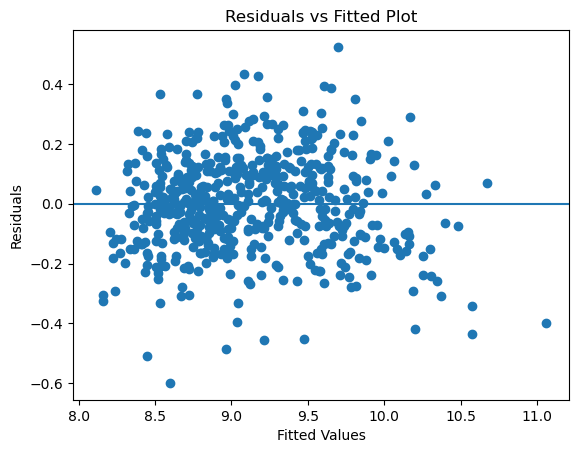

In [37]:
plt.scatter(full_model.fittedvalues, full_model.resid)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Plot")
plt.show()

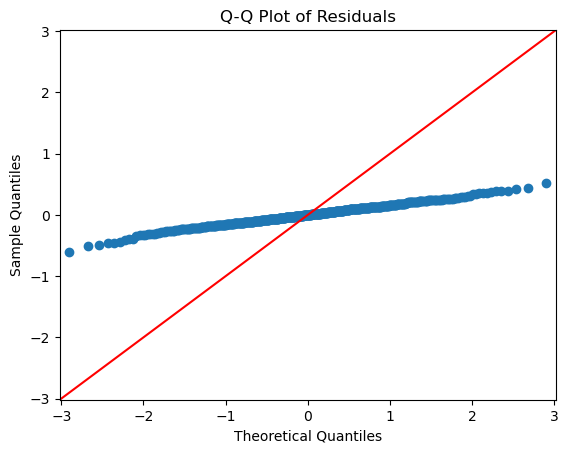

In [38]:
sm.qqplot(full_model.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

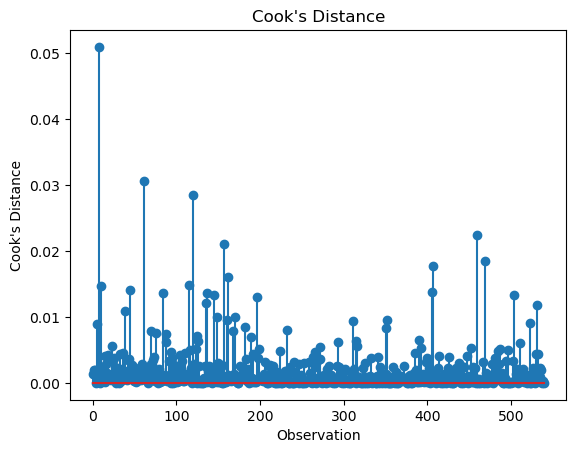


Number of Outliers Removed: 33


In [39]:
model_temp = sm.OLS(y, sm.add_constant(X)).fit()
influence = model_temp.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(cooks)
plt.title("Cook's Distance")
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.show()

threshold = 4 / len(train)
outliers = np.where(cooks > threshold)[0]

print("\nNumber of Outliers Removed:", len(outliers))

train_clean = train.drop(index=outliers)

X_clean = train_clean.drop(columns=['price'])
y_clean = train_clean['price']

In [40]:
def best_subset(X, y):
    predictors = X.columns
    best_adj_r2 = -np.inf
    best_combo = None
    best_model = None

    for k in range(1, len(predictors)+1):
        for combo in itertools.combinations(predictors, k):
            X_subset = sm.add_constant(X[list(combo)])
            model = sm.OLS(y, X_subset).fit()
            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                best_combo = combo
                best_model = model

    return best_combo, best_model
    
best_predictors, best_model = best_subset(X_clean, y_clean)

print("\nBest Predictors:", best_predictors)
print(best_model.summary())



Best Predictors: ('area', 'bedrooms', 'bathrooms', 'stories', 'guestroom', 'basement', 'airconditioning', 'parking')

Best Model Sumary
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     827.8
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          4.59e-282
Time:                        11:02:44   Log-Likelihood:                 287.92
No. Observations:                 507   AIC:                            -557.8
Df Residuals:                     498   BIC:                            -519.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025  

In [41]:
variables_of_interest = ['guestroom', 'basement',
                         'hotwaterheating', 'airconditioning']

print("\nVariable Significance")
for var in variables_of_interest:
    if var in best_predictors:
        coef = best_model.params[var]
        pval = best_model.pvalues[var]
        print(f"{var}: Coefficient = {coef:.4f}, p-value = {pval:.4f}")
    else:
        print(f"{var}: Not included in best model")



Variable Significance
guestroom: Coefficient = 0.0223, p-value = 0.2152
basement: Coefficient = 0.1485, p-value = 0.0000
hotwaterheating: Not included in best model (not significant)
airconditioning: Coefficient = -0.0192, p-value = 0.1895


In [42]:
model_columns = best_model.model.exog_names
X_test_const = sm.add_constant(test.drop(columns=['price']), has_constant='add')
X_test_const = X_test_const[model_columns]
y_test = test['price']
y_pred = best_model.predict(X_test_const)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE) Test Set:", mse)


MSE Prediction on Test Set
Mean Squared Error (MSE): 0.03436949505211789
